# PerceptionMetrics CityScapes image segmentation tutorial
Cityscapes is a popular dataset for benchmarking image segmentation algorithms. In this tutorial, we will show how to use PerceptionMetrics to evaluate the performance of an image segmentation model on the Cityscapes dataset.

## Download required data

To run this tutorial, you will need to download the Cityscapes dataset and the pretrained SegFormer model. You can download the Cityscapes dataset from the [Cityscapes website](https://www.cityscapes-dataset.com/downloads/). Save the ground truth and image data in a local directory, e.g., `local/data/cityscapes`. 

### Config File Setup

In [2]:
import json
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation

model_name = "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"

processor = AutoImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

cfg = processor.to_dict()

pm_cfg = {
    "resize": {
        "height": cfg["size"]["height"],
        "width": cfg["size"]["width"],
    },
    "normalization": {
        "mean": list(cfg["image_mean"]),
        "std": list(cfg["image_std"]),
    },

}

model_cfg_path = "local/data/segformer_cityscapes_cfg.json"

with open(model_cfg_path, "w", encoding="utf-8") as f:
    json.dump(pm_cfg, f, indent=2)

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.


## Setup Model

In [3]:
!pip install transformers

from transformers import SegformerForSemanticSegmentation
from perceptionmetrics.datasets.cityscapes import build_dataset_ontology
from perceptionmetrics.models.torch_segmentation import TorchImageSegmentationModel

model_ontology_path = "local/data/cityscapes_trainid_ontology.json"
build_dataset_ontology(
    use_train_id=True,
    ontology_fname=model_ontology_path,
)

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"
)

pm_model = TorchImageSegmentationModel(
    model=model,
    model_cfg="local/data/segformer_cityscapes_cfg.json",
    ontology_fname=model_ontology_path,
)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Torch detection not available
Tensorflow not available


/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/tejass/miniconda3/envs/pm/lib/python3.11/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any fe

## Setup Dataset

The dataset is loaded with raw Cityscapes label IDs. Evaluation translates those labels to the model train-ID ontology in memory.


In [4]:
from perceptionmetrics.datasets.cityscapes import (
    CityscapesImageSegmentationDataset,
    build_train_id_ontology_translation,
)

dataset = CityscapesImageSegmentationDataset(
    # train_dataset_root="local/data/cityscapes",
    val_dataset_root="local/data/cityscapes",
    use_train_id=False,
)

ontology_translation = build_train_id_ontology_translation()
translation_path = "local/data/cityscapes_labelid_to_trainid_translation.json"
with open(translation_path, "w", encoding="utf-8") as f:
    json.dump(ontology_translation, f, indent=2)


Samples retrieved: 500


## Inference

Image filename: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/examples/local/data/cityscapes/leftImg8bit_trainvaltest/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png


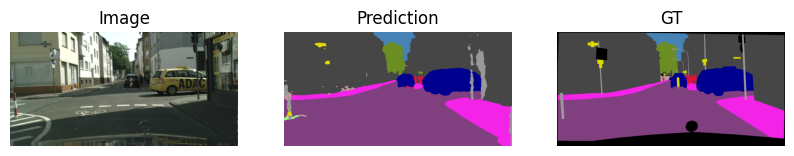

In [5]:
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image

from perceptionmetrics.utils import conversion as uc

image_fname = Path(dataset.dataset["image"].iloc[0])
if dataset.dataset_dir is not None and not image_fname.is_absolute():
    image_fname = Path(dataset.dataset_dir) / image_fname
print(f"Image filename: {image_fname}")
image = Image.open(image_fname)

label_fname = Path(dataset.dataset["label"].iloc[0])
if dataset.dataset_dir is not None and not label_fname.is_absolute():
    label_fname = Path(dataset.dataset_dir) / label_fname
label = Image.open(label_fname)
label = uc.label_to_rgb(label, dataset.ontology)

pred = pm_model.predict(image)
pred = uc.label_to_rgb(pred, pm_model.ontology)
pred = pred.resize(label.size)

plt.figure(figsize=(10, 10))
plt.subplot(131), plt.title("Image"), plt.imshow(np.array(image)), plt.axis("off")
plt.subplot(132), plt.title("Prediction"), plt.imshow(np.array(pred)), plt.axis("off")
plt.subplot(133), plt.title("GT"), plt.imshow(np.array(label)), plt.axis("off")
plt.show()


## Evaluation

In [6]:
results = pm_model.eval(
    dataset,
    split="val",
    ontology_translation=translation_path,
    translation_direction="dataset_to_model",
)
display(results)


100%|██████████| 500/500 [00:30<00:00, 16.53it/s]


,road,sidewalk,building,wall,fence,pole,traffic light,traffic sign,vegetation,terrain,...,person,rider,car,truck,bus,train,motorcycle,bicycle,macro,micro
tp,5.337558e+07,5.089295e+06,2.374317e+07,4.406190e+05,5.924300e+05,7.057000e+05,8.890600e+04,4.204500e+05,1.886205e+07,6.356570e+05,...,1.038398e+06,7.473900e+04,6.997446e+06,2.295700e+05,3.028020e+05,1.030790e+05,3.527900e+04,5.783380e+05,NaN,NaN
fp,7.103430e+05,1.540499e+06,4.381416e+06,2.829190e+05,9.118020e+05,8.268050e+05,3.822900e+04,2.027010e+05,2.537619e+06,2.827720e+05,...,5.492430e+05,5.531500e+04,7.869440e+05,9.575200e+04,7.396300e+04,9.418500e+04,1.978700e+04,2.957370e+05,NaN,NaN
fn,6.078598e+06,1.123114e+06,1.437458e+06,4.016140e+05,3.503450e+05,9.905020e+05,1.372700e+05,3.431750e+05,1.034860e+06,3.201240e+05,...,4.525940e+05,1.725190e+05,4.847220e+05,1.157480e+05,1.428790e+05,2.586400e+04,5.603800e+04,2.362170e+05,NaN,NaN
tn,7.090748e+07,1.233191e+08,1.015100e+08,1.299468e+08,1.292174e+08,1.285490e+08,1.308076e+08,1.301057e+08,1.086375e+08,1.298334e+08,...,1.290318e+08,1.307694e+08,1.228029e+08,1.306309e+08,1.305524e+08,1.308489e+08,1.309609e+08,1.299617e+08,NaN,NaN
precision,9.868664e-01,7.676400e-01,8.442140e-01,6.089784e-01,3.938422e-01,4.604879e-01,6.993039e-01,6.747161e-01,8.814178e-01,6.921134e-01,...,6.540509e-01,5.746767e-01,8.989074e-01,7.056701e-01,8.036893e-01,5.225434e-01,6.406676e-01,6.616572e-01,0.703715,0.892450
recall,8.977600e-01,8.192144e-01,9.429141e-01,5.231557e-01,6.283896e-01,4.160471e-01,3.930833e-01,5.505975e-01,9.479889e-01,6.650655e-01,...,6.964477e-01,3.022713e-01,9.352164e-01,6.648075e-01,6.794142e-01,7.994152e-01,3.863355e-01,7.100048e-01,0.679370,0.892450
accuracy,9.482045e-01,9.796782e-01,9.556055e-01,9.947774e-01,9.903706e-01,9.861350e-01,9.986610e-01,9.958353e-01,9.727441e-01,9.954003e-01,...,9.923566e-01,9.982618e-01,9.902980e-01,9.983864e-01,9.983456e-01,9.990841e-01,9.994215e-01,9.959415e-01,0.988679,0.988679
f1_score,9.402067e-01,7.925891e-01,8.908386e-01,5.628141e-01,4.842079e-01,4.371409e-01,5.032733e-01,6.063705e-01,9.134921e-01,6.783199e-01,...,6.745838e-01,3.961655e-01,9.167025e-01,6.846296e-01,7.363450e-01,6.319852e-01,4.820095e-01,6.849789e-01,0.681078,0.892450
iou,8.871604e-01,6.564369e-01,8.031640e-01,3.916084e-01,3.194421e-01,2.797059e-01,3.362493e-01,4.351016e-01,8.407598e-01,5.132255e-01,...,5.089600e-01,2.470115e-01,8.462149e-01,5.204843e-01,5.827105e-01,4.619725e-01,3.175313e-01,5.208882e-01,0.543530,0.805788
dice_score,9.402067e-01,7.925891e-01,8.908386e-01,5.628141e-01,4.842079e-01,4.371409e-01,5.032733e-01,6.063705e-01,9.134921e-01,6.783199e-01,...,6.745838e-01,3.961655e-01,9.167025e-01,6.846296e-01,7.363450e-01,6.319852e-01,4.820095e-01,6.849789e-01,0.681078,0.892450
